Ejemplo para verificar reconstrucción de espectro direccional

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import envelope_celeris as e

Tabla de Celeris de ejemplo: [A, T, theta_deg, phi]

T cortos + h grande => |κ| grande => la envolvente cabe sin problemas


In [2]:
!head waves_original.txt


[NumberOfWaves] 738
0.0119509      29.4118    -0.349056      0.58137
0.0125489      29.4118    -0.261792      2.09838
0.0129925      29.4118    -0.174528      4.09054
0.0132655      29.4118   -0.0872639      3.16607
0.0133577      29.4118            0       3.3358
0.0132655      29.4118    0.0872639      2.38203
0.0129925      29.4118     0.174528      4.83105


a, T, dir, fase

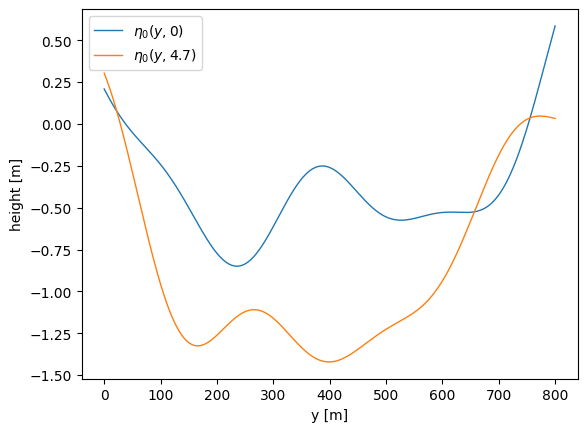

In [3]:
table0 =np.loadtxt("./waves_original.txt", skiprows=3)
# table0 = np.array([
#     [0.10,  4.0,   0.0, 0.0],
#     [0.06,  2.0,  10.0, 0.5],
#     # [0.04,  5.0,  -5.0, 1.2],
# ])
h = 10.0  # profundidad

ymin = 0 
ymax = 800
y = np.linspace(ymin, ymax, 4001)
eta_0 = e.eta_from_table(table0, h, y, t=0.0)
eta_0_t = e.eta_from_table(table0, h, y, t=4.7)

plt.plot(y, eta_0, lw=1.0, label=r"$\eta_0(y,0)$")
plt.plot(y, eta_0_t, lw=1.0, label=r"$\eta_0(y,4.7)$")
plt.xlabel("y [m]")
plt.ylabel("height [m]")
plt.legend()

In [4]:
17 * np.sqrt(9.81 * 10) * np.sin(np.deg2rad(20))

np.float64(57.58841288652677)

In [12]:
table0[:,1].max()

np.float64(29.4118)

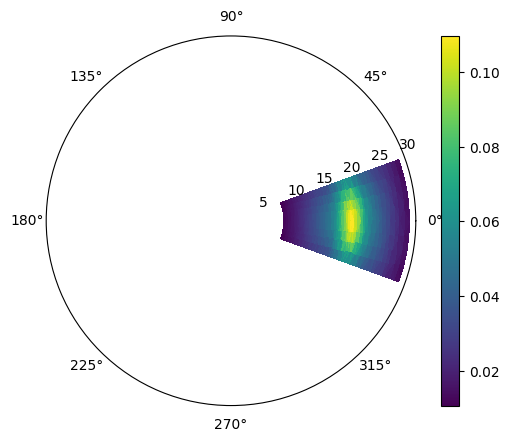

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

# Asumiendo:
# table0[:, 2] -> Theta (radianes)
# table0[:, 1] -> Radio (r)
# table0[:, 0] -> Valores (Z)

mesh = ax.tripcolor((table0[:, 2]), table0[:, 1], table0[:, 0], cmap='viridis')

fig.colorbar(mesh, ax=ax)
plt.show()


Envolvente: rectangular suavizada con erf, soporte en `[a,b] = [300, 600] m`

σ controla la suavidad; valores más grandes => menos leakage espectral,

mejor reconstrucción dentro de los modos propagantes.


In [6]:
env = e.erf_rectangle(a=300, b=600.0, sigma=10.0)

# y_max = 60 m: la nueva tabla debe reconstruir bien hasta ahí
table1 = e.apply_envelope_to_table(
    table0, h, env, y_max=ymax,
    pad=0, samples_per_lobe=1, amplitude_threshold=1e-3,
)

print(f"Tabla original:  {table0.shape[0]} modos")
print(f"Tabla con env.:  {table1.shape[0]} modos  ({env.name})")


Tabla original:  738 modos
Tabla con env.:  10782 modos  (erf(σ=10))


Guardar a archivo

In [7]:
header = (f"\n[NumberOfWaves] {table1.shape[0]}\n" +
"=================================")

np.savetxt("waves_truncated.txt", table1, fmt='%.5f', header=header, comments="" )
!head waves_truncated.txt


[NumberOfWaves] 10782
0.00118 29.41180 -1.12354 -0.23715
0.00170 29.41180 -0.80569 -1.99802
0.00208 29.41180 -0.57161 2.52430
0.00223 29.41180 -0.36897 0.76343
0.00213 29.41180 -0.18132 -0.99744
0.00179 29.41180 0.00000 -2.75831
0.00129 29.41180 0.18132 1.76401


Verificación: comparar eta_0(y,0)*B(y) con eta_1(y,0) reconstruida

In [8]:
target = eta_0 * env.B(y)
eta_1 = e.eta_from_table(table1, h, y, t=0.0)

err = np.sqrt(np.mean((eta_1 - target) ** 2))

rel = err / np.sqrt(np.mean(target ** 2))
print(f"RMS reconstrucción en y∈[-60,60]: {err:.3e} m  (rel: {rel:.2%})")


RMS reconstrucción en y∈[-60,60]: 7.482e-02 m  (rel: 27.32%)


También en otro instante para chequear la dependencia temporal

In [9]:
ntrunc = -1
eta_0_t = e.eta_from_table(table0[:ntrunc,:], h, y[:ntrunc], t=3.7)
target_t = eta_0_t * env.B(y[:ntrunc])
eta_1_t = e.eta_from_table(table1[:ntrunc,:], h, y[:ntrunc], t=3.7)
err_t = np.sqrt(np.mean((eta_1_t - target_t) ** 2))
rel_t = err_t / np.sqrt(np.mean(target_t ** 2))
print(f"RMS reconstrucción en t=3.7 :    {err_t:.3e} m  (rel: {rel_t:.2%})")

RMS reconstrucción en t=3.7 :    1.406e-01 m  (rel: 18.75%)


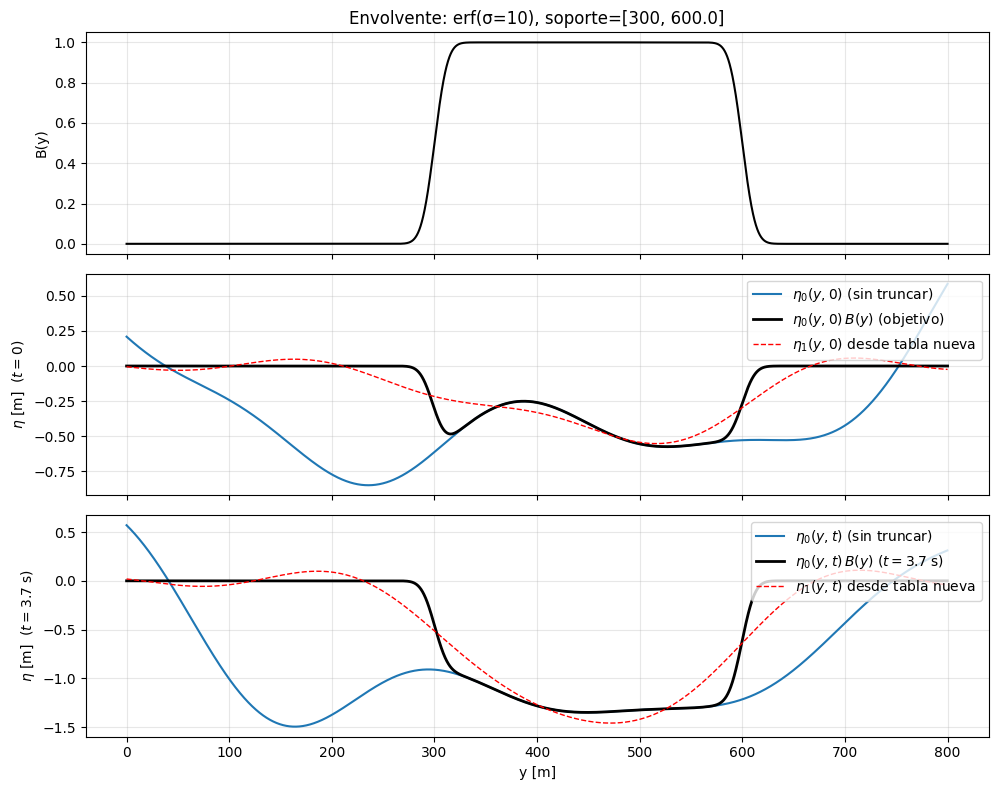

In [10]:
# Plot de verificación
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(y, env.B(y), 'k-')
axes[0].set_ylabel("B(y)")
axes[0].set_title(f"Envolvente: {env.name}, soporte=[{env.a}, {env.b}]")
axes[0].grid(alpha=0.3)


axes[1].plot(y, eta_0, label=r"$\eta_0(y,0)$ (sin truncar)") 
axes[1].plot(y, target, 'k-',  lw=2.0, label=r"$\eta_0(y,0)\,B(y)$ (objetivo)")
axes[1].plot(y, eta_1,  'r--', lw=1.0, label=r"$\eta_1(y,0)$ desde tabla nueva")
axes[1].set_ylabel(r"$\eta$ [m]  ($t=0$)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)
# axes[1].set_ylim(0,0.18)

axes[2].plot(y[:ntrunc], eta_0_t, label=r"$\eta_0(y,t)$ (sin truncar)") 
axes[2].plot(y[:ntrunc], target_t, 'k-',  lw=2.0, label=r"$\eta_0(y,t)\,B(y)$ ($t=3.7$ s)")
axes[2].plot(y[:ntrunc], eta_1_t,  'r--', lw=1.0, label=r"$\eta_1(y,t)$ desde tabla nueva")
axes[2].set_xlabel("y [m]")
axes[2].set_ylabel(r"$\eta$ [m]  ($t=3.7$ s)")
axes[2].legend(loc="upper right")
axes[2].grid(alpha=0.3)
# axes[2].set_ylim(0,0.18)

plt.tight_layout()
# plt.savefig("envelope_check.png", dpi=120)
